import library

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

load data set

In [3]:
df = pd.read_csv(
    "data/comment.csv"
)

df.head()

,Student_ID,Comment,Sentiment
0,1,Some lectures are difficult to follow because ...,Negative
1,2,"Faculty is helpful, but more doubt sessions wo...",Neutral
2,3,The course structure is reasonable with a few ...,Neutral
3,4,The course has a good balance between theory a...,Positive
4,5,The course meets expectations but could provid...,Neutral


cheack data

In [4]:
df.head()
df.shape

(1000, 3)

In [5]:
print(df.columns)

Index(['Student_ID', 'Comment', 'Sentiment'], dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Student_ID  1000 non-null   int64 
 1   Comment     1000 non-null   object
 2   Sentiment   1000 non-null   object
dtypes: int64(1), object(2)
memory usage: 23.6+ KB


cheack missing value

In [7]:
df.isnull().sum()

Student_ID    0
Comment       0
Sentiment     0
dtype: int64

In [8]:
df.head()

,Student_ID,Comment,Sentiment
0,1,Some lectures are difficult to follow because ...,Negative
1,2,"Faculty is helpful, but more doubt sessions wo...",Neutral
2,3,The course structure is reasonable with a few ...,Neutral
3,4,The course has a good balance between theory a...,Positive
4,5,The course meets expectations but could provid...,Neutral


Sentiment Distribution

In [9]:
df["Sentiment"].value_counts()

Sentiment
Positive    334
Negative    333
Neutral     333
Name: count, dtype: int64

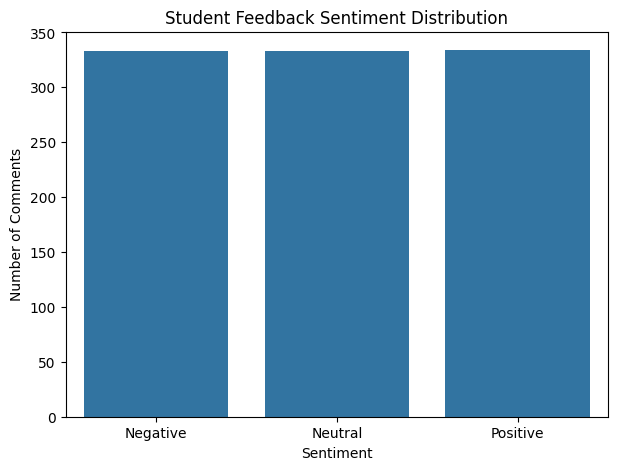

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Student Feedback Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")

plt.show()

duplicate

In [11]:
print(
    "Duplicate comments:",
    df["Comment"].duplicated().sum()
)

Duplicate comments: 499


In [12]:
df = df.drop_duplicates(
    subset=["Comment"]
).reset_index(drop=True)

df.shape

(501, 3)

Text Cleaning Function

In [13]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )

    # Remove numbers
    text = re.sub(
        r"\d+",
        "",
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

In [14]:
test_text = "Teacher is VERY Good!!!"

print("Original:")
print(test_text)

print("\nCleaned:")
print(clean_text(test_text))

Original:
Teacher is VERY Good!!!

Cleaned:
teacher is very good


In [15]:
df["Cleaned_Comment"] = ( df["Comment"].apply(clean_text))

In [16]:
df[["Comment", "Cleaned_Comment"]].head()

,Comment,Cleaned_Comment
0,Some lectures are difficult to follow because ...,some lectures are difficult to follow because ...
1,"Faculty is helpful, but more doubt sessions wo...",faculty is helpful but more doubt sessions wou...
2,The course structure is reasonable with a few ...,the course structure is reasonable with a few ...
3,The course has a good balance between theory a...,the course has a good balance between theory a...
4,The course meets expectations but could provid...,the course meets expectations but could provid...


In [17]:
X = df["Cleaned_Comment"]

y = df["Sentiment"]

In [18]:
print(X.shape)
print(y.shape)

(501,)
(501,)


80% → Training
20% → Testing

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 400
Testing data: 101


TF-IDF Vectorizer

In [21]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

TF-IDF Fit

In [22]:
X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

In [23]:
print(
    "Training TF-IDF shape:",
    X_train_tfidf.shape
)

print(
    "Testing TF-IDF shape:",
    X_test_tfidf.shape
)

Training TF-IDF shape: (400, 843)
Testing TF-IDF shape: (101, 843)


In [24]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [25]:
model.fit(
    X_train_tfidf,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Prediction

In [26]:
y_pred = model.predict(
    X_test_tfidf
)

print(y_pred[:20])

['Neutral' 'Neutral' 'Neutral' 'Negative' 'Negative' 'Positive' 'Neutral'
 'Negative' 'Positive' 'Positive' 'Positive' 'Neutral' 'Negative'
 'Neutral' 'Positive' 'Negative' 'Neutral' 'Negative' 'Positive'
 'Negative']


In [27]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Accuracy: 100.0 %


In [28]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        33
     Neutral       1.00      1.00      1.00        34
    Positive       1.00      1.00      1.00        34

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101



In [29]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[33  0  0]
 [ 0 34  0]
 [ 0  0 34]]


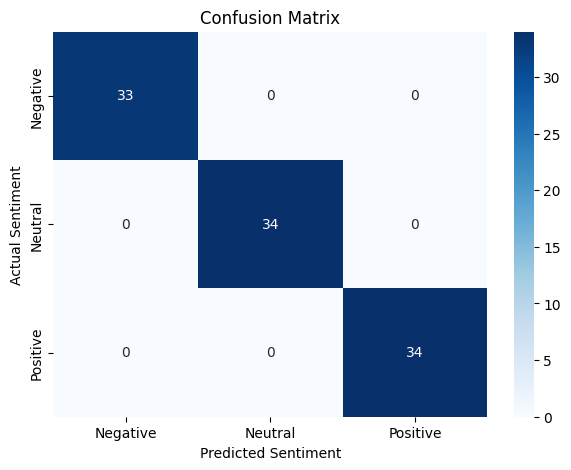

In [30]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix")

plt.show()

In [31]:
new_comment = [
    "The teacher explains concepts very clearly and helps students with doubts."
]

In [32]:
new_comment_clean = [
    clean_text(comment)
    for comment in new_comment
]

In [33]:
new_comment_tfidf = tfidf.transform(
    new_comment_clean
)

In [34]:
prediction = model.predict(
    new_comment_tfidf
)

print(
    "Predicted Sentiment:",
    prediction[0]
)

Predicted Sentiment: Positive


In [35]:
test_comments = [
    "The teacher is excellent and very supportive.",
    "The laboratory equipment is poor.",
    "The course is okay but needs more practical examples."
]

clean_comments = [
    clean_text(comment)
    for comment in test_comments
]

vectors = tfidf.transform(
    clean_comments
)

predictions = model.predict(
    vectors
)

for comment, prediction in zip(
    test_comments,
    predictions
):
    print("Comment:", comment)
    print("Sentiment:", prediction)
    print("-" * 60)

Comment: The teacher is excellent and very supportive.
Sentiment: Positive
------------------------------------------------------------
Comment: The laboratory equipment is poor.
Sentiment: Negative
------------------------------------------------------------
Comment: The course is okay but needs more practical examples.
Sentiment: Neutral
------------------------------------------------------------


In [36]:
probabilities = model.predict_proba(
    new_comment_tfidf
)

print(probabilities)

[[0.13167838 0.14047995 0.72784167]]


In [37]:
for sentiment, probability in zip(
    model.classes_,
    probabilities[0]
):
    print(
        sentiment,
        ":",
        round(probability * 100, 2),
        "%"
    )

Negative : 13.17 %
Neutral : 14.05 %
Positive : 72.78 %


In [38]:
model_data = {
    "model": model,
    "tfidf": tfidf
}

In [39]:
joblib.dump(
    model_data,
    "sentiment_model.pkl"
)

['sentiment_model.pkl']

In [40]:
loaded_data = joblib.load(
    "sentiment_model.pkl"
)

loaded_model = loaded_data["model"]
loaded_tfidf = loaded_data["tfidf"]

In [41]:
test = [
    "not good."
]

test_clean = [
    clean_text(x)
    for x in test
]

test_vector = loaded_tfidf.transform(
    test_clean
)

result = loaded_model.predict(
    test_vector
)

print("Prediction:", result[0])

Prediction: Positive


In [42]:
test_comments = [
    "The teacher explains concepts very clearly and is very supportive.",
    "The laboratory equipment is poor and needs improvement.",
    "The course is okay but needs more practical examples.",
    "Faculty members are excellent and always help students.",
    "The lectures are too fast and difficult to understand.",
    "The classroom environment is satisfactory.",
    "The instructor gives excellent guidance for projects.",
    "Study material is not provided on time.",
    "The practical sessions are useful but could be longer."
]

clean_comments = [
    clean_text(comment)
    for comment in test_comments
]

test_vectors = tfidf.transform(clean_comments)

predictions = model.predict(test_vectors)

for comment, prediction in zip(
    test_comments,
    predictions
):
    print("Comment :", comment)
    print("Prediction :", prediction)
    print("-" * 70)

Comment : The teacher explains concepts very clearly and is very supportive.
Prediction : Positive
----------------------------------------------------------------------
Comment : The laboratory equipment is poor and needs improvement.
Prediction : Negative
----------------------------------------------------------------------
Comment : The course is okay but needs more practical examples.
Prediction : Neutral
----------------------------------------------------------------------
Comment : Faculty members are excellent and always help students.
Prediction : Positive
----------------------------------------------------------------------
Comment : The lectures are too fast and difficult to understand.
Prediction : Negative
----------------------------------------------------------------------
Comment : The classroom environment is satisfactory.
Prediction : Neutral
----------------------------------------------------------------------
Comment : The instructor gives excellent guidance for

ividual Comment Test Function

Ab ek function bana dete hain jisme aap koi bhi feedback enter kar sakte ho.

In [43]:
def predict_feedback(comment):

    cleaned = clean_text(comment)

    vector = tfidf.transform([cleaned])

    prediction = model.predict(vector)[0]

    probability = model.predict_proba(vector)[0]

    confidence = max(probability) * 100

    print("Feedback:")
    print(comment)

    print("\nPredicted Sentiment:")
    print(prediction)

    print("\nConfidence:")
    print(round(confidence, 2), "%")

In [44]:
predict_feedback(
    "mujhe ache se nhi padate hai"
)

Feedback:
mujhe ache se nhi padate hai

Predicted Sentiment:
Positive

Confidence:
34.58 %


cheack model